# Soal 1a - Web Scraping Dataset Berita Olahraga Indonesia

In [1]:
# !pip install trafilatura beautifulsoup4 fake-useragent tqdm requests lxml pandas matplotlib seaborn --quiet

In [ ]:
import requests
import time
import random
import re
import os
import json
import csv
import logging
from datetime import datetime
from typing import Dict, List, Optional, Tuple, Any
from dataclasses import dataclass, field, asdict
from urllib.parse import urljoin, urlparse
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from tqdm import tqdm

try:
    import trafilatura
    from trafilatura.settings import use_config
    TRAFILATURA_AVAILABLE = True
except ImportError:
    TRAFILATURA_AVAILABLE = False
    print("[PERINGATAN] trafilatura tidak tersedia. Akan menggunakan BeautifulSoup saja.")

try:
    from fake_useragent import UserAgent
    UA = UserAgent()
    FAKE_UA_AVAILABLE = True
except ImportError:
    FAKE_UA_AVAILABLE = False
    print("[PERINGATAN] fake-useragent tidak tersedia. Akan menggunakan daftar User-Agent manual.")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger(__name__)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

print("Semua library berhasil diimpor.")
print(f"trafilatura tersedia: {TRAFILATURA_AVAILABLE}")
print(f"fake-useragent tersedia: {FAKE_UA_AVAILABLE}")

Semua library berhasil diimpor.
trafilatura tersedia: True
fake-useragent tersedia: True


## Konfigurasi Source

Konfigurasi sumber data menggunakan pendekatan URL-based labeling.
Setiap source didefinisikan dengan:
- `base_url`: URL halaman kategori
- `label`: label kelas yang diberikan berdasarkan kategori URL
- `media`: nama media sumber
- `pages`: jumlah halaman pagination yang akan di-scrape

Label ditentukan dari kategori URL resmi media, bukan dari keyword matching.
Contoh: semua artikel dari `sport.detik.com/sepakbola/liga-inggris` dilabeli `liga_inggris`.

In [ ]:
MANUAL_USER_AGENTS: List[str] = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:121.0) Gecko/20100101 Firefox/121.0",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.2 Safari/605.1.15",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Edge/120.0.0.0 Safari/537.36",
    "Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:121.0) Gecko/20100101 Firefox/121.0",
]


def get_random_user_agent() -> str:
    if FAKE_UA_AVAILABLE:
        try:
            return UA.random
        except Exception:
            pass
    return random.choice(MANUAL_USER_AGENTS)

SESSION_USER_AGENT = get_random_user_agent()

@dataclass
class SourceConfig:
    base_url: str
    label: str
    media: str
    pages: int
    index_url_template: str
    article_url_pattern: str

SOURCES: List[SourceConfig] = [
    SourceConfig(
        base_url="https://sport.detik.com/sepakbola/liga-inggris",
        label="liga_inggris",
        media="detik",
        pages=30,
        index_url_template="https://sport.detik.com/sepakbola/liga-inggris/indeks?page={page}",
        article_url_pattern=r"sport\.detik\.com/.+/d-\d+/"
    ),
    SourceConfig(
        base_url="https://sport.detik.com/sepakbola/liga-italia",
        label="liga_italia",
        media="detik",
        pages=30,
        index_url_template="https://sport.detik.com/sepakbola/liga-italia/indeks?page={page}",
        article_url_pattern=r"sport\.detik\.com/.+/d-\d+/"
    ),
    SourceConfig(
        base_url="https://sport.detik.com/sepakbola/liga-spanyol",
        label="liga_spanyol",
        media="detik",
        pages=30,
        index_url_template="https://sport.detik.com/sepakbola/liga-spanyol/indeks?page={page}",
        article_url_pattern=r"sport\.detik\.com/.+/d-\d+/"
    ),
    SourceConfig(
        base_url="https://sport.detik.com/sepakbola/liga-indonesia",
        label="liga_indonesia",
        media="detik",
        pages=30,
        index_url_template="https://sport.detik.com/sepakbola/liga-indonesia/indeks?page={page}",
        article_url_pattern=r"sport\.detik\.com/.+/d-\d+/"
    ),
    SourceConfig(
        base_url="https://sport.detik.com/raket",
        label="non_sepak_bola",
        media="detik",
        pages=25,
        index_url_template="https://sport.detik.com/raket/indeks?page={page}",
        article_url_pattern=r"sport\.detik\.com/.+/d-\d+/"
    ),
    SourceConfig(
        base_url="https://sport.detik.com/basket",
        label="non_sepak_bola",
        media="detik",
        pages=15,
        index_url_template="https://sport.detik.com/basket/indeks?page={page}",
        article_url_pattern=r"sport\.detik\.com/.+/d-\d+/"
    ),
    SourceConfig(
        base_url="https://sport.detik.com/sport-lain",
        label="non_sepak_bola",
        media="detik",
        pages=20,
        index_url_template="https://sport.detik.com/sport-lain/indeks?page={page}",
        article_url_pattern=r"sport\.detik\.com/.+/d-\d+/"
    ),
    SourceConfig(
        base_url="https://sport.detik.com/moto-gp",
        label="non_sepak_bola",
        media="detik",
        pages=15,
        index_url_template="https://sport.detik.com/moto-gp/indeks?page={page}",
        article_url_pattern=r"sport\.detik\.com/.+/d-\d+/"
    ),
    SourceConfig(
        base_url="https://sport.detik.com/f1",
        label="non_sepak_bola",
        media="detik",
        pages=15,
        index_url_template="https://sport.detik.com/f1/indeks?page={page}",
        article_url_pattern=r"sport\.detik\.com/.+/d-\d+/"
    ),
    SourceConfig(
        base_url="https://bola.kompas.com/liga-inggris",
        label="liga_inggris",
        media="kompas",
        pages=20,
        index_url_template="https://bola.kompas.com/liga-inggris/{page}",
        article_url_pattern=r"kompas\.com/read/"
    ),
    SourceConfig(
        base_url="https://bola.kompas.com/liga-italia",
        label="liga_italia",
        media="kompas",
        pages=20,
        index_url_template="https://bola.kompas.com/liga-italia/{page}",
        article_url_pattern=r"kompas\.com/read/"
    ),
    SourceConfig(
        base_url="https://bola.kompas.com/liga-spanyol",
        label="liga_spanyol",
        media="kompas",
        pages=20,
        index_url_template="https://bola.kompas.com/liga-spanyol/{page}",
        article_url_pattern=r"kompas\.com/read/"
    ),
    SourceConfig(
        base_url="https://bola.kompas.com/liga-indonesia",
        label="liga_indonesia",
        media="kompas",
        pages=20,
        index_url_template="https://bola.kompas.com/liga-indonesia/{page}",
        article_url_pattern=r"kompas\.com/read/"
    ),
    SourceConfig(
        base_url="https://www.kompas.com/sports",
        label="non_sepak_bola",
        media="kompas",
        pages=15,
        index_url_template="https://www.kompas.com/sports/{page}",
        article_url_pattern=r"kompas\.com/read/"
    ),
    SourceConfig(
        base_url="https://www.kompas.com/motogp",
        label="non_sepak_bola",
        media="kompas",
        pages=15,
        index_url_template="https://www.kompas.com/motogp/{page}",
        article_url_pattern=r"kompas\.com/read/"
    ),
    SourceConfig(
        base_url="https://www.kompas.com/badminton",
        label="non_sepak_bola",
        media="kompas",
        pages=15,
        index_url_template="https://www.kompas.com/badminton/{page}",
        article_url_pattern=r"kompas\.com/read/"
    ),
    SourceConfig(
        base_url="https://www.liputan6.com/bola/liga-inggris",
        label="liga_inggris",
        media="liputan6",
        pages=20,
        index_url_template="https://www.liputan6.com/bola/liga-inggris?page={page}",
        article_url_pattern=r"liputan6\.com/bola/read/\d+/"
    ),
    SourceConfig(
        base_url="https://www.liputan6.com/bola/liga-italia",
        label="liga_italia",
        media="liputan6",
        pages=20,
        index_url_template="https://www.liputan6.com/bola/liga-italia?page={page}",
        article_url_pattern=r"liputan6\.com/bola/read/\d+/"
    ),
    SourceConfig(
        base_url="https://www.liputan6.com/bola/liga-spanyol",
        label="liga_spanyol",
        media="liputan6",
        pages=20,
        index_url_template="https://www.liputan6.com/bola/liga-spanyol?page={page}",
        article_url_pattern=r"liputan6\.com/bola/read/\d+/"
    ),
    SourceConfig(
        base_url="https://www.liputan6.com/bola/liga-nasional",
        label="liga_indonesia",
        media="liputan6",
        pages=20,
        index_url_template="https://www.liputan6.com/bola/liga-nasional?page={page}",
        article_url_pattern=r"liputan6\.com/bola/read/\d+/"
    ),
    SourceConfig(
        base_url="https://www.liputan6.com/bola/sports",
        label="non_sepak_bola",
        media="liputan6",
        pages=30,
        index_url_template="https://www.liputan6.com/bola/sports?page={page}",
        article_url_pattern=r"liputan6\.com/.+/read/\d+/"
    ),
]

OUTPUT_DIR = "output"
CHECKPOINT_DIR = "checkpoints"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

TARGET_PER_LABEL: Dict[str, int] = {
    "liga_inggris": 400,
    "liga_italia": 400,
    "liga_spanyol": 400,
    "liga_indonesia": 400,
    "non_sepak_bola": 800,
}

TARGET_PER_LABEL_MEDIA: Dict[str, Dict[str, int]] = {
    "liga_inggris": {
        "detik": 100,
        "kompas": 250,
        "liputan6": 50,
    },
    "liga_italia": {
        "detik": 100,
        "kompas": 250,
        "liputan6": 50,
    },
    "liga_spanyol": {
        "detik": 100,
        "kompas": 250,
        "liputan6": 50,
    },
    "liga_indonesia": {
        "detik": 100,
        "kompas": 250,
        "liputan6": 50,
    },
    "non_sepak_bola": {
        "detik": 652,
        "kompas": 60,
        "liputan6": 88,
    },
}

print(f"Total sumber yang dikonfigurasi: {len(SOURCES)}")
print(f"Total target artikel: {sum(TARGET_PER_LABEL.values())}")
print("\nTARGET_PER_LABEL_MEDIA = {")
for label, media_targets in TARGET_PER_LABEL_MEDIA.items():
    print(f"    {label!r}: {media_targets},")
print("}")

print("\nVerifikasi total per label:")
for label, target in TARGET_PER_LABEL.items():
    sources_for_label = [s for s in SOURCES if s.label == label]
    media_set = sorted(set(s.media for s in sources_for_label))
    media_total = sum(TARGET_PER_LABEL_MEDIA[label].values())
    print(
        f"  {label}: target={target}, distribusi={media_total}, "
        f"sumber={len(sources_for_label)} ({', '.join(media_set)})"
    )

total_keseluruhan = sum(
    sum(media_targets.values()) for media_targets in TARGET_PER_LABEL_MEDIA.values()
)
print(f"\nTotal keseluruhan distribusi: {total_keseluruhan}")

Total sumber yang dikonfigurasi: 21
Total target artikel: 2400

TARGET_PER_LABEL_MEDIA = {
    'liga_inggris': {'detik': 100, 'kompas': 250, 'liputan6': 50},
    'liga_italia': {'detik': 100, 'kompas': 250, 'liputan6': 50},
    'liga_spanyol': {'detik': 100, 'kompas': 250, 'liputan6': 50},
    'liga_indonesia': {'detik': 100, 'kompas': 250, 'liputan6': 50},
    'non_sepak_bola': {'detik': 652, 'kompas': 60, 'liputan6': 88},
}

Verifikasi total per label:
  liga_inggris: target=400, distribusi=400, sumber=3 (detik, kompas, liputan6)
  liga_italia: target=400, distribusi=400, sumber=3 (detik, kompas, liputan6)
  liga_spanyol: target=400, distribusi=400, sumber=3 (detik, kompas, liputan6)
  liga_indonesia: target=400, distribusi=400, sumber=3 (detik, kompas, liputan6)
  non_sepak_bola: target=800, distribusi=800, sumber=9 (detik, kompas, liputan6)

Total keseluruhan distribusi: 2400


## Fungsi HTTP Request

Fungsi `fetch_page()` mengimplementasikan:
- Random User-Agent untuk menghindari blocking
- Timeout 30 detik agar tidak hang
- Retry mechanism 3 kali dengan exponential backoff
- Delay acak 1-3 detik antar request untuk menghormati server
- Error handling menyeluruh dengan logging
- Menggunakan `requests.Session()` untuk connection pooling

In [ ]:
class HTTPClient:

    def __init__(self, max_retries: int = 3, timeout: int = 30, min_delay: float = 1.0, max_delay: float = 3.0):
        self.max_retries = max_retries
        self.timeout = timeout
        self.min_delay = min_delay
        self.max_delay = max_delay
        self.session = requests.Session()
        self._request_count = 0
        self.session_user_agent = SESSION_USER_AGENT
        self.last_status_code: Optional[int] = None
        self.last_html_length: int = 0
        self.last_url: Optional[str] = None

    def _get_headers(self) -> Dict[str, str]:
        return {
            "User-Agent": self.session_user_agent,
            "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
            "Accept-Language": "id-ID,id;q=0.9,en-US;q=0.8,en;q=0.7",
            "Accept-Encoding": "gzip, deflate, br",
            "Connection": "keep-alive",
            "Cache-Control": "no-cache",
            "Upgrade-Insecure-Requests": "1",
        }

    def fetch_page(self, url: str) -> Optional[str]:
        self.last_status_code = None
        self.last_html_length = 0
        self.last_url = url

        for attempt in range(1, self.max_retries + 1):
            try:
                # Delay acak antar request
                if self._request_count > 0:
                    delay = random.uniform(self.min_delay, self.max_delay)
                    time.sleep(delay)

                self._request_count += 1
                headers = self._get_headers()

                response = self.session.get(
                    url,
                    headers=headers,
                    timeout=self.timeout,
                    allow_redirects=True
                )
                self.last_status_code = response.status_code
                self.last_url = response.url

                if response.status_code == 200:
                    self.last_html_length = len(response.text or "")
                    return response.text
                elif response.status_code == 403:
                    logger.warning(
                        f"[Percobaan {attempt}/{self.max_retries}] "
                        f"403 Forbidden: {url}"
                    )
                elif response.status_code == 404:
                    logger.warning(f"404 Not Found: {url}")
                    return None  # Tidak perlu retry untuk 404
                else:
                    logger.warning(
                        f"[Percobaan {attempt}/{self.max_retries}] "
                        f"Status {response.status_code}: {url}"
                    )

            except requests.exceptions.Timeout:
                self.last_status_code = None
                self.last_html_length = 0
                logger.warning(
                    f"[Percobaan {attempt}/{self.max_retries}] "
                    f"Timeout: {url}"
                )
            except requests.exceptions.ConnectionError:
                self.last_status_code = None
                self.last_html_length = 0
                logger.warning(
                    f"[Percobaan {attempt}/{self.max_retries}] "
                    f"Connection Error: {url}"
                )
            except requests.exceptions.RequestException as e:
                self.last_status_code = None
                self.last_html_length = 0
                logger.warning(
                    f"[Percobaan {attempt}/{self.max_retries}] "
                    f"Request Error: {url} -- {str(e)}"
                )

            if attempt < self.max_retries:
                backoff = 2 ** attempt + random.uniform(0, 1)
                logger.info(f"Menunggu {backoff:.1f} detik sebelum retry...")
                time.sleep(backoff)

        logger.error(f"Gagal mengambil halaman setelah {self.max_retries} percobaan: {url}")
        return None

    def close(self) -> None:
        self.session.close()
        logger.info(f"Session ditutup. Total request: {self._request_count}")

http_client = HTTPClient(max_retries=3, timeout=30, min_delay=1.0, max_delay=3.0)
print("HTTP client berhasil diinisialisasi.")

HTTP client berhasil diinisialisasi.


## Fungsi Pengambilan URL Artikel

Fungsi `generate_article_urls()` melakukan:
- Membaca halaman kategori/indeks berdasarkan konfigurasi source
- Membaca pagination dari halaman 1 hingga halaman N
- Mengumpulkan semua URL artikel dari setiap halaman
- Menghilangkan duplikasi URL menggunakan set
- Memvalidasi URL agar hanya artikel yang valid (bukan galeri, video, atau kategori)

Setiap media memiliki pola URL yang berbeda sehingga parser dibuat per-media.

In [ ]:
def extract_urls_from_detik(html: str, base_url: str) -> List[str]:
    soup = BeautifulSoup(html, "lxml")
    urls = []

    for link in soup.find_all("a", href=True):
        href = link["href"]
        if re.search(r"/d-\d+/", href):
            full_url = urljoin(base_url, href)
            urls.append(full_url)

    return urls


def extract_urls_from_kompas(html: str, base_url: str) -> List[str]:
    soup = BeautifulSoup(html, "lxml")

    def normalize_kompas_article_url(raw_url: str) -> Optional[str]:
        full_url = urljoin(base_url, raw_url.strip())
        parsed = urlparse(full_url)

        if "kompas.com" not in parsed.netloc.lower():
            return None
        if "/read/" not in parsed.path:
            return None

        kept_query_parts = []
        for part in parsed.query.split("&"):
            if not part:
                continue
            key = part.split("=", 1)[0].lower()
            if key == "page" or key.startswith("utm_"):
                continue
            kept_query_parts.append(part)

        normalized = parsed._replace(
            query="&".join(kept_query_parts),
            fragment=""
        )
        return normalized.geturl()

    selector_groups = [
        "div.latest--news a.article__link[href]",
        "div.latest--news a[href]",
        ".latest--news a.article__link[href]",
        "a.article__link[href]",
        "div.articleList a[href]",
        "div.indeks_news a[href]",
        "h3 a[href]",
        "h2 a[href]",
        "a[href]",
    ]

    urls: List[str] = []
    seen: set = set()

    for selector in selector_groups:
        matches = soup.select(selector)
        if not matches:
            continue

        for link in matches:
            href = link.get("href", "").strip()
            if not href:
                continue

            normalized_url = normalize_kompas_article_url(href)
            if normalized_url and normalized_url not in seen:
                seen.add(normalized_url)
                urls.append(normalized_url)

        if urls:
            break

    if not urls:
        raw_href_pattern = re.compile(
            r'href=["\']([^"\']*kompas\.com/read/[^"\']*)["\']',
            re.IGNORECASE
        )
        for match in raw_href_pattern.finditer(html):
            raw_href = match.group(1)
            normalized_url = normalize_kompas_article_url(raw_href)
            if normalized_url and normalized_url not in seen:
                seen.add(normalized_url)
                urls.append(normalized_url)

    return urls


def extract_kompas_pagination_urls(
    html: str,
    current_url: str,
    base_url: str
) -> List[str]:
    soup = BeautifulSoup(html, "lxml")
    base_parsed = urlparse(base_url)
    current_parsed = urlparse(current_url)
    base_path = base_parsed.path.rstrip("/")

    pagination_urls: List[str] = []
    seen_urls: set = set()

    def add_candidate(raw_href: str) -> None:
        href = (raw_href or "").strip()
        if not href or href.lower().startswith("javascript:"):
            return

        full_url = urljoin(current_url, href)
        parsed = urlparse(full_url)
        normalized_url = parsed._replace(query="", fragment="").geturl()

        if parsed.netloc.lower() != base_parsed.netloc.lower():
            return
        if not (
            parsed.path.rstrip("/") == base_path
            or parsed.path.startswith(base_path + "/")
        ):
            return
        if normalized_url == current_parsed._replace(query="", fragment="").geturl():
            return
        if normalized_url in seen_urls:
            return

        seen_urls.add(normalized_url)
        pagination_urls.append(normalized_url)

    selector_groups = [
        "a.paging__link[href][data-ci-pagination-page]",
        "a.paging__link[href]",
        ".paging a[href]",
        ".pagination a[href]",
    ]

    for selector in selector_groups:
        for link in soup.select(selector):
            add_candidate(link.get("href", ""))

    for link in soup.find_all("a", href=True):
        href = link.get("href", "")
        full_url = urljoin(current_url, href)
        parsed = urlparse(full_url)
        if parsed.netloc.lower() != base_parsed.netloc.lower():
            continue
        if re.fullmatch(rf"{re.escape(base_path)}/\d+", parsed.path.rstrip("/")):
            add_candidate(href)

    if not pagination_urls:
        regex_patterns = [
            r'href=["\']([^"\']*/\d+)["\']\s+data-ci-pagination-page=["\']\d+["\']',
            r'href=["\']([^"\']*bola\.kompas\.com/[^"\']*/\d+)["\']',
        ]
        for pattern in regex_patterns:
            for match in re.finditer(pattern, html, flags=re.IGNORECASE):
                add_candidate(match.group(1))

    return pagination_urls


def test_kompas_pagination() -> None:
    test_url_base = "https://bola.kompas.com/liga-inggris"
    logger.info("=" * 60)
    logger.info("TESTING KOMPAS PAGINATION")
    logger.info("=" * 60)

    visited_pages: set = set()
    pending_pages: List[str] = [test_url_base]
    all_article_urls: set = set()

    while pending_pages:
        page_url = pending_pages.pop(0)
        if page_url in visited_pages:
            continue

        visited_pages.add(page_url)
        html = http_client.fetch_page(page_url)
        if html is None:
            logger.warning(f"Gagal mengambil halaman uji: {page_url}")
            continue

        article_urls = extract_urls_from_kompas(html, page_url)
        all_article_urls.update(article_urls)
        pagination_urls = extract_kompas_pagination_urls(html, page_url, test_url_base)

        logger.info(f"Halaman diproses: {page_url}")
        logger.info(f"Pagination ditemukan ({len(pagination_urls)}): {pagination_urls}")
        logger.info(f"Artikel dari halaman ini: {len(article_urls)}")

        for next_page_url in pagination_urls:
            if next_page_url not in visited_pages and next_page_url not in pending_pages:
                pending_pages.append(next_page_url)

    logger.info(f"Jumlah halaman pagination: {len(visited_pages)}")
    logger.info(f"Seluruh URL pagination: {sorted(visited_pages)}")
    logger.info(f"Jumlah artikel unik yang ditemukan: {len(all_article_urls)}")
    logger.info("=" * 60)


def extract_urls_from_liputan6(html: str, base_url: str) -> List[str]:
    soup = BeautifulSoup(html, "lxml")
    urls = []

    for link in soup.find_all("a", href=True):
        href = link["href"]
        if re.search(r"/read/\d+/", href):
            full_url = urljoin("https://www.liputan6.com", href)
            urls.append(full_url)

    return urls


def is_valid_article_url(url: str) -> bool:
    invalid_patterns = [
        r"/foto/",
        r"/video/",
        r"/galeri/",
        r"/gallery/",
        r"/infografis/",
        r"/indeks",
        r"/jadwal",
        r"/klasemen",
        r"/live-score",
        r"/profil-tim/",
        r"/man-of-the-match",
        r"/tag/",
        r"/topik/",
        r"/sitemap",
        r"/info/",
        r"/auth/",
        r"\?page=",
        r"#",
    ]

    url_lower = url.lower()
    for pattern in invalid_patterns:
        if re.search(pattern, url_lower):
            return False

    return True


def generate_article_urls(source: SourceConfig) -> List[str]:
    all_urls: set = set()
    url_extractor = {
        "detik": extract_urls_from_detik,
        "kompas": extract_urls_from_kompas,
        "liputan6": extract_urls_from_liputan6,
    }

    extractor = url_extractor.get(source.media)
    if extractor is None:
        logger.error(f"Tidak ada URL extractor untuk media: {source.media}")
        return []

    logger.info(
        f"Mengumpulkan URL dari {source.media} -- {source.label} "
        f"({source.pages} halaman)"
    )

    if source.media == "kompas":
        def normalize_kompas_url(raw_url: str) -> Optional[str]:
            full_url = urljoin(source.base_url, raw_url.strip())
            parsed = urlparse(full_url)

            if "kompas.com" not in parsed.netloc.lower():
                return None
            if "/read/" not in parsed.path:
                return None

            kept_query_parts = []
            for part in parsed.query.split("&"):
                if not part:
                    continue
                key = part.split("=", 1)[0].lower()
                if key == "page" or key.startswith("utm_"):
                    continue
                kept_query_parts.append(part)

            normalized = parsed._replace(
                query="&".join(kept_query_parts),
                fragment=""
            )
            return normalized.geturl()

        visited_pages: set = set()
        pending_pages: List[str] = [source.base_url]
        fallback_mode_enabled = False
        fallback_candidates: List[str] = []

        while pending_pages and len(visited_pages) < source.pages:
            page_url = pending_pages.pop(0)
            if page_url in visited_pages:
                continue

            visited_pages.add(page_url)
            html = http_client.fetch_page(page_url)
            status_code = http_client.last_status_code
            html_length = http_client.last_html_length

            logger.info(f"  [Kompas] URL halaman: {page_url}")
            logger.info(
                f"  [Kompas] Status code: {status_code}, HTML length: {html_length}"
            )

            if html is None:
                logger.warning(f"  [Kompas] Gagal mengambil halaman: {page_url}")
                continue

            raw_urls = extractor(html, page_url)
            normalized_valid_urls: List[str] = []
            for url in raw_urls:
                normalized_url = normalize_kompas_url(url)
                if normalized_url:
                    normalized_valid_urls.append(normalized_url)

            unique_valid_urls = list(dict.fromkeys(normalized_valid_urls))
            new_urls = [u for u in unique_valid_urls if u not in all_urls]
            duplicate_urls = len(unique_valid_urls) - len(new_urls)
            all_urls.update(new_urls)

            pagination_urls = extract_kompas_pagination_urls(
                html=html,
                current_url=page_url,
                base_url=source.base_url
            )

            logger.info(
                f"  [Kompas] Halaman diproses: {len(visited_pages)} | "
                f"artikel ditemukan: {len(unique_valid_urls)} | "
                f"baru: {len(new_urls)} | duplikat: {duplicate_urls}"
            )
            logger.info(
                f"  [Kompas] Pagination ditemukan ({len(pagination_urls)}): {pagination_urls}"
            )

            if not pagination_urls and not fallback_mode_enabled and page_url == source.base_url:
                fallback_mode_enabled = True
                fallback_candidates = [
                    f"{source.base_url}/{page_num}"
                    for page_num in range(2, source.pages + 1)
                ]
                logger.info(
                    f"  [Kompas] Pagination HTML kosong, aktifkan fallback probing: "
                    f"{fallback_candidates[:10]}"
                )

            for next_page_url in pagination_urls:
                if next_page_url not in visited_pages and next_page_url not in pending_pages:
                    pending_pages.append(next_page_url)

            if fallback_mode_enabled:
                while fallback_candidates:
                    candidate_url = fallback_candidates.pop(0)
                    if candidate_url not in visited_pages and candidate_url not in pending_pages:
                        pending_pages.append(candidate_url)
                        break

    else:
        for page in range(1, source.pages + 1):
            page_url = source.index_url_template.format(page=page)
            html = http_client.fetch_page(page_url)

            if html is None:
                logger.warning(f"Gagal mengambil halaman {page}: {page_url}")
                continue

            urls = extractor(html, page_url)

            valid_urls = [u for u in urls if is_valid_article_url(u)]
            new_urls = set(valid_urls) - all_urls
            all_urls.update(new_urls)

            logger.info(
                f"  Halaman {page}: ditemukan {len(urls)} URL, "
                f"{len(valid_urls)} valid, {len(new_urls)} baru "
                f"(total: {len(all_urls)})"
            )

    result = list(all_urls)
    logger.info(
        f"Selesai: {source.media}/{source.label} -- "
        f"total {len(result)} URL unik"
    )
    return result


print("Fungsi pengambilan URL berhasil didefinisikan.")

Fungsi pengambilan URL berhasil didefinisikan.


## Fungsi Ekstraksi Isi Artikel

Menggunakan dua metode ekstraksi:
1. **trafilatura** sebagai extractor utama -- library khusus untuk ekstraksi
konten utama artikel berita, mampu membuang navigasi, iklan, dan sidebar.
2. **BeautifulSoup** sebagai fallback -- digunakan jika trafilatura gagal
atau menghasilkan konten kosong.

Data yang diekstrak: `title`, `content`, `date`.
Kolom `text` dibentuk dari penggabungan `title` dan `content`.

In [ ]:
@dataclass
class ArticleData:
    title: str = ""
    content: str = ""
    text: str = ""
    date: str = ""
    url: str = ""
    media: str = ""
    label: str = ""


def extract_with_trafilatura(html: str, url: str) -> Optional[Dict[str, str]]:
    if not TRAFILATURA_AVAILABLE:
        return None

    try:
        config = use_config()
        config.set("DEFAULT", "EXTRACTION_TIMEOUT", "30")

        result = trafilatura.extract(
            html,
            url=url,
            include_comments=False,
            include_tables=False,
            no_fallback=False,
            favor_precision=True,
            config=config
        )

        if result is None or len(result.strip()) < 50:
            return None

        metadata = trafilatura.extract(
            html,
            url=url,
            output_format="json",
            include_comments=False,
            config=config
        )

        title = ""
        date = ""

        if metadata:
            try:
                meta_dict = json.loads(metadata)
                title = meta_dict.get("title", "")
                date = meta_dict.get("date", "")
            except (json.JSONDecodeError, TypeError):
                pass

        if not title:
            soup = BeautifulSoup(html, "lxml")
            title_tag = soup.find("title")
            if title_tag:
                title = title_tag.get_text(strip=True)
                # Hapus suffix nama media dari title
                for suffix in [" - detikSport", " - Bolasport.com", " - Liputan6.com", " | detikSport", " | Bolasport", " | Liputan6"]:
                    title = title.replace(suffix, "")

        return {
            "title": title.strip(),
            "content": result.strip(),
            "date": date.strip()
        }

    except Exception as e:
        logger.debug(f"trafilatura gagal untuk {url}: {str(e)}")
        return None


def extract_with_beautifulsoup(html: str, url: str, media: str) -> Optional[Dict[str, str]]:
    try:
        soup = BeautifulSoup(html, "lxml")
        title = ""
        content = ""
        date = ""

        if media == "detik":
            title_el = soup.find("h1", class_="detail__title")
            if not title_el:
                title_el = soup.find("h1")
            if title_el:
                title = title_el.get_text(strip=True)

            body_el = soup.find("div", class_="detail__body-text")
            if body_el:
                for unwanted in body_el.find_all(["script", "style", "iframe", "ins"]):
                    unwanted.decompose()
                for unwanted in body_el.find_all("div", class_=re.compile(r"(ad|banner|promo|related)")):
                    unwanted.decompose()
                paragraphs = body_el.find_all("p")
                content = " ".join(p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True))

            date_el = soup.find("div", class_="detail__date")
            if date_el:
                date = date_el.get_text(strip=True)

        elif media == "kompas":
            title_el = soup.find("h1")
            if title_el:
                title = title_el.get_text(strip=True)

            body_el = soup.find("div", class_="read__content")
            if not body_el:
                body_el = soup.find("article")
            
            if body_el:
                for unwanted in body_el.find_all(["script", "style", "iframe", "ins"]):
                    unwanted.decompose()
                paragraphs = body_el.find_all("p")
                content = " ".join(p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True))

            date_meta = soup.find('meta', attrs={'name': 'content_PublishedDate'})
            if date_meta and date_meta.get('content'):
                date = date_meta['content'].strip()
            else:
                date_meta_alt = soup.find('meta', property='article:published_time')
                if date_meta_alt and date_meta_alt.get('content'):
                    date = date_meta_alt['content'].strip()
                else:
                    date_el = soup.find("div", class_="read__time")
                    if date_el:
                        date = date_el.get_text(strip=True).replace('Kompas.com,', '').strip()

        elif media == "liputan6":
            title_el = soup.find("h1", class_="read-page--header--title")
            if not title_el:
                title_el = soup.find("h1")
            if title_el:
                title = title_el.get_text(strip=True)

            body_el = soup.find("div", class_="article-content-body__item-content")
            if not body_el:
                body_el = soup.find("div", class_="read-page--content-body")
            if not body_el:
                body_el = soup.find("article")
            if body_el:
                for unwanted in body_el.find_all(["script", "style", "iframe", "ins"]):
                    unwanted.decompose()
                paragraphs = body_el.find_all("p")
                content = " ".join(p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True))

            date_el = soup.find("time", class_="read-page--header--author__datetime")
            if not date_el:
                date_el = soup.find("time")
            if date_el:
                date = date_el.get("datetime", date_el.get_text(strip=True))

        if not title:
            title_tag = soup.find("title")
            if title_tag:
                title = title_tag.get_text(strip=True)
                for suffix in [" - detikSport", " - Liputan6.com", " - Kompas.com", " | detikSport", " | Liputan6", " | Kompas.com"]:
                    title = title.replace(suffix, "")

        if not content:
            return None

        return {
            "title": title.strip(),
            "content": content.strip(),
            "date": date.strip()
        }

    except Exception as e:
        logger.debug(f"BeautifulSoup gagal untuk {url}: {str(e)}")
        return None


def extract_article(url: str, media: str, label: str) -> Optional[ArticleData]:
    html = http_client.fetch_page(url)
    if html is None:
        return None

    # Metode 1: trafilatura (utama)
    result = extract_with_trafilatura(html, url)

    # Metode 2: BeautifulSoup (fallback)
    if result is None:
        result = extract_with_beautifulsoup(html, url, media)

    if result is None:
        return None

    title = result.get("title", "")
    content = result.get("content", "")
    date = result.get("date", "")

    # Gabungkan title dan content menjadi text
    if title and content:
        text = f"{title}. {content}"
    elif title:
        text = title
    elif content:
        text = content
    else:
        text = ""

    article = ArticleData(
        title=title,
        content=content,
        text=text,
        date=date,
        url=url,
        media=media,
        label=label
    )

    return article


print("Fungsi ekstraksi artikel berhasil didefinisikan.")

# Keywords untuk validasi konsistensi label
LABEL_KEYWORDS = {
    "liga_inggris": ["liga inggris", "premier league", "manchester", "liverpool", "chelsea", "arsenal", "man city", "tottenham"],
    "liga_italia": ["liga italia", "serie a", "juventus", "inter milan", "ac milan", "roma", "napoli", "lazio"],
    "liga_spanyol": ["liga spanyol", "la liga", "real madrid", "barcelona", "atletico", "sevilla", "valencia"],
    "liga_indonesia": ["liga indonesia", "liga 1", "persija", "persib", "persebaya", "psm", "bali united", "arema", "pssi"],
    "non_sepak_bola": ["badminton", "bulu tangkis", "motogp", "f1", "basket", "nba", "tenis", "voli", "atletik"]
}

# Keywords negatif untuk label sepak bola (mencegah badminton masuk liga_italia)
NON_FOOTBALL_KEYWORDS = [
    "all england", "badminton", "bwf", "thomas cup", "uber cup", "raket",
    "motogp", "marquez", "valentino rossi", "formula 1", "f1", "hamilton", "verstappen",
    "nba", "basket", "lebron", "tenis", "grand slam", "djokovic", "federer", "nadal"
]

def validate_label_consistency(text: str, label: str) -> Tuple[bool, str]:
    text_lower = text.lower()
    
    # Kata kunci olahraga non-sepakbola (NEGATIF untuk label liga)
    non_football_keywords = [
        "badminton", "all england", "bwf", "thomas cup", "uber cup", "raket",
        "motogp", "moto gp", "grand prix", "formula 1", "f1", "scuderia",
        "nba", "basket", "basketball", "ibl",
        "voli", "volleyball", "proliga",
        "tenis", "tennis", "grand slam", "wimbledon",
        "atletik", "maraton", "renang", "swimming"
    ]

    football_labels = ["liga_inggris", "liga_italia", "liga_spanyol", "liga_indonesia"]

    if label in football_labels:
        for keyword in non_football_keywords:
            if keyword in text_lower:
                return False, f"mislabeling (ditemukan keyword non-sepakbola: {keyword})"

    return True, "valid"

Fungsi ekstraksi artikel berhasil didefinisikan.


In [ ]:
@dataclass
class RejectedArticle:
    url: str
    media: str
    label: str
    reason: str


def validate_article(article: ArticleData) -> Tuple[bool, str]:
    if not article.text or not article.text.strip():
        return False, "text kosong"

    word_count = len(article.text.split())
    if word_count < 100:
        return False, f"terlalu pendek ({word_count} kata, minimal 100)"

    is_consistent, reason = validate_label_consistency(article.text, article.label)
    if not is_consistent:
        return False, reason
    
    url_lower = article.url.lower()
    gallery_patterns = ["/foto/", "/galeri/", "/gallery/", "/photo/", "/infografis/"]
    for pattern in gallery_patterns:
        if pattern in url_lower:
            return False, f"halaman galeri (pola: {pattern})"

    gallery_keywords = ["galeri foto", "photo gallery", "kumpulan foto"]
    text_lower = article.text.lower()[:200]
    for keyword in gallery_keywords:
        if keyword in text_lower:
            return False, f"konten galeri (keyword: {keyword})"

    video_patterns = ["/video/", "/20detik/", "/watch/"]
    for pattern in video_patterns:
        if pattern in url_lower:
            return False, f"halaman video (pola: {pattern})"

    category_patterns = ["/indeks", "/tag/", "/topik/", "/klasemen", "/jadwal"]
    for pattern in category_patterns:
        if pattern in url_lower:
            return False, f"halaman kategori (pola: {pattern})"

    return True, "valid"


print("Fungsi validasi artikel berhasil didefinisikan.")

Fungsi validasi artikel berhasil didefinisikan.


## Pipeline Scraping

Pipeline utama yang mengorkestrasi seluruh proses scraping:
1. Iterasi setiap source yang sudah dikonfigurasi
2. Kumpulkan URL artikel dari setiap source
3. Ekstrak konten dari setiap URL
4. Validasi setiap artikel
5. Simpan checkpoint setiap 100 artikel
6. Lanjutkan dari checkpoint terakhir jika ditemukan

**Checkpoint System**: Setiap 100 artikel yang berhasil diproses,
state scraping disimpan ke file JSON. Jika proses terputus (misalnya
Colab disconnect), notebook dapat melanjutkan dari posisi terakhir.

In [ ]:
def get_checkpoint_path() -> str:
    return os.path.join(CHECKPOINT_DIR, "scraping_checkpoint.json")


def save_checkpoint(articles: List[Dict], rejected: List[Dict],
                    processed_urls: set, source_index: int,
                    url_index: int, label_media_counts: Dict) -> None:
    checkpoint = {
        "articles": articles,
        "rejected": rejected,
        "processed_urls": list(processed_urls),
        "source_index": source_index,
        "url_index": url_index,
        "label_media_counts": {f"{k[0]}|{k[1]}": v for k, v in label_media_counts.items()},
        "timestamp": datetime.now().isoformat()
    }

    path = get_checkpoint_path()
    with open(path, "w", encoding="utf-8") as f:
        json.dump(checkpoint, f, ensure_ascii=False, indent=2)

    logger.info(
        f"Checkpoint disimpan: {len(articles)} artikel, "
        f"{len(rejected)} ditolak, source={source_index}, url={url_index}"
    )


def load_checkpoint() -> Optional[Dict]:
    path = get_checkpoint_path()
    if not os.path.exists(path):
        return None

    try:
        with open(path, "r", encoding="utf-8") as f:
            checkpoint = json.load(f)

        logger.info(f"Checkpoint ditemukan! ({checkpoint.get('timestamp', 'unknown')})")
        logger.info(f"  Artikel berhasil: {len(checkpoint.get('articles', []))}")
        logger.info(f"  URL diproses: {len(checkpoint.get('processed_urls', []))}")
        return checkpoint

    except (json.JSONDecodeError, Exception) as e:
        logger.warning(f"Checkpoint rusak, akan memulai dari awal: {str(e)}")
        return None


def run_scraping_pipeline() -> Tuple[List[Dict], List[Dict]]:
    checkpoint = load_checkpoint()

    if checkpoint:
        articles = checkpoint.get("articles", [])
        rejected = checkpoint.get("rejected", [])
        processed_urls = set(checkpoint.get("processed_urls", []))
        start_source_idx = checkpoint.get("source_index", 0)
        start_url_idx = checkpoint.get("url_index", 0)
        
        # Restore label_media_counts
        lmc_raw = checkpoint.get("label_media_counts", {})
        label_media_counts = {}
        for k, v in lmc_raw.items():
            try:
                label, media = k.split("|")
                label_media_counts[(label, media)] = v
            except ValueError:
                pass
            
        logger.info("Melanjutkan dari checkpoint terakhir...")
    else:
        articles = []
        rejected = []
        processed_urls = set()
        start_source_idx = 0
        start_url_idx = 0
        label_media_counts = {}
        logger.info("Memulai scraping dari awal...")
    labels_list = list(TARGET_PER_LABEL.keys())
    media_list = ["detik", "kompas", "liputan6"]
    
    round_robin_sources = []
    for label in labels_list:
        for media in media_list:
            matching = [s for s in SOURCES if s.label == label and s.media == media]
            round_robin_sources.extend(matching)

    logger.info("="*60)
    logger.info("PHASE 1: Mengumpulkan URL (Round-Robin Media-Label)")
    logger.info("="*60)

    all_source_urls: List[List[str]] = []
    for idx, source in enumerate(round_robin_sources):
        current = label_media_counts.get((source.label, source.media), 0)
        target = TARGET_PER_LABEL_MEDIA[source.label].get(source.media, 0)
        
        if current >= target:
            all_source_urls.append([])
            continue
            
        urls = generate_article_urls(source)
        urls = [u for u in urls if u not in processed_urls]
        all_source_urls.append(urls)

    logger.info("="*60)
    logger.info("PHASE 2: Ekstraksi Konten")
    logger.info("="*60)

    total_articles_processed = len(articles)
    checkpoint_interval = 50 

    for src_idx, source in enumerate(round_robin_sources):
        if src_idx < start_source_idx:
            continue
            
        urls = all_source_urls[src_idx]
        if not urls:
            continue

        label = source.label
        media = source.media
        target = TARGET_PER_LABEL_MEDIA[label].get(media, 0)

        logger.info(f"\nSource {src_idx+1}/{len(round_robin_sources)}: {media} | {label}")
        
        url_start = start_url_idx if src_idx == start_source_idx else 0
        
        for url_idx in tqdm(range(url_start, len(urls)), desc=f"{media}/{label}"):
            if label_media_counts.get((label, media), 0) >= target:
                logger.info(f"Kuota {label}/{media} terpenuhi ({target}).")
                break
                
            url = urls[url_idx]
            if url in processed_urls: continue
            processed_urls.add(url)

            article = extract_article(url, media, label)
            if article is None:
                rejected.append(asdict(RejectedArticle(url, media, label, "gagal ekstraksi")))
                continue

            is_valid, reason = validate_article(article)
            if not is_valid:
                rejected.append(asdict(RejectedArticle(url, media, label, reason)))
                continue

            articles.append({
                "text": article.text,
                "media": article.media,
                "label": article.label,
                "url": article.url,
                "date": article.date
            })
            
            label_media_counts[(label, media)] = label_media_counts.get((label, media), 0) + 1
            total_articles_processed += 1

            if total_articles_processed % checkpoint_interval == 0:
                save_checkpoint(articles, rejected, processed_urls, src_idx, url_idx, label_media_counts)

        start_url_idx = 0 

    save_checkpoint(articles, rejected, processed_urls, len(round_robin_sources), 0, label_media_counts)

    logger.info("="*60)
    logger.info("SCRAPING SELESAI")
    logger.info(f"Total Berhasil : {len(articles)}")
    logger.info(f"Total Ditolak  : {len(rejected)}")
    logger.info("="*60)

    return articles, rejected


print("Pipeline scraping berhasil didefinisikan.")
print("Jalankan run_scraping_pipeline() untuk memulai proses scraping.")

Pipeline scraping berhasil didefinisikan.
Jalankan run_scraping_pipeline() untuk memulai proses scraping.


In [ ]:
for source in SOURCES:

    if source.media != "kompas":
        continue

    urls = generate_article_urls(source)

    print(f"{source.media:10s} | {source.label:15s} | {len(urls):4d} URL | base_url={source.base_url}")
    if urls:
        print(f"             contoh URL: {urls[0]}")
    else:
        print("             [PERINGATAN] Tidak ada URL yang ditemukan untuk source ini!")

2026-06-24 19:03:17 [INFO] Mengumpulkan URL dari kompas -- liga_inggris (20 halaman)
2026-06-24 19:03:17 [INFO]   [Kompas] URL halaman: https://bola.kompas.com/liga-inggris
2026-06-24 19:03:17 [INFO]   [Kompas] Status code: 200, HTML length: 172167
2026-06-24 19:03:17 [INFO]   [Kompas] Halaman diproses: 1 | artikel ditemukan: 25 | baru: 25 | duplikat: 0
2026-06-24 19:03:17 [INFO]   [Kompas] Pagination ditemukan (3): ['https://bola.kompas.com/liga-inggris/2', 'https://bola.kompas.com/liga-inggris/3', 'https://bola.kompas.com/liga-inggris/10']
2026-06-24 19:03:18 [INFO]   [Kompas] URL halaman: https://bola.kompas.com/liga-inggris/2
2026-06-24 19:03:18 [INFO]   [Kompas] Status code: 200, HTML length: 172405
2026-06-24 19:03:18 [INFO]   [Kompas] Halaman diproses: 2 | artikel ditemukan: 25 | baru: 25 | duplikat: 0
2026-06-24 19:03:18 [INFO]   [Kompas] Pagination ditemukan (4): ['https://bola.kompas.com/liga-inggris', 'https://bola.kompas.com/liga-inggris/3', 'https://bola.kompas.com/liga-in

kompas     | liga_inggris    |  250 URL | base_url=https://bola.kompas.com/liga-inggris
             contoh URL: https://bola.kompas.com/read/2026/05/18/21560058/link-live-arsenal-vs-burnley-di-pekan-ke-37-liga-inggris-2025-2026


2026-06-24 19:03:38 [INFO]   [Kompas] URL halaman: https://bola.kompas.com/liga-italia
2026-06-24 19:03:38 [INFO]   [Kompas] Status code: 200, HTML length: 171880
2026-06-24 19:03:38 [INFO]   [Kompas] Halaman diproses: 1 | artikel ditemukan: 25 | baru: 25 | duplikat: 0
2026-06-24 19:03:38 [INFO]   [Kompas] Pagination ditemukan (3): ['https://bola.kompas.com/liga-italia/2', 'https://bola.kompas.com/liga-italia/3', 'https://bola.kompas.com/liga-italia/10']
2026-06-24 19:03:41 [INFO]   [Kompas] URL halaman: https://bola.kompas.com/liga-italia/2
2026-06-24 19:03:41 [INFO]   [Kompas] Status code: 200, HTML length: 163645
2026-06-24 19:03:41 [INFO]   [Kompas] Halaman diproses: 2 | artikel ditemukan: 25 | baru: 25 | duplikat: 0
2026-06-24 19:03:41 [INFO]   [Kompas] Pagination ditemukan (4): ['https://bola.kompas.com/liga-italia', 'https://bola.kompas.com/liga-italia/3', 'https://bola.kompas.com/liga-italia/4', 'https://bola.kompas.com/liga-italia/10']
2026-06-24 19:03:43 [INFO]   [Kompas] URL

kompas     | liga_italia     |  250 URL | base_url=https://bola.kompas.com/liga-italia
             contoh URL: https://bola.kompas.com/read/2026/05/31/11572638/kaget-prestasi-como-mirwan-suwarso-singgung-masa-depan-fabregas-dan-nico-paz


2026-06-24 19:04:03 [INFO]   [Kompas] URL halaman: https://bola.kompas.com/liga-spanyol
2026-06-24 19:04:03 [INFO]   [Kompas] Status code: 200, HTML length: 172066
2026-06-24 19:04:03 [INFO]   [Kompas] Halaman diproses: 1 | artikel ditemukan: 25 | baru: 25 | duplikat: 0
2026-06-24 19:04:03 [INFO]   [Kompas] Pagination ditemukan (3): ['https://bola.kompas.com/liga-spanyol/2', 'https://bola.kompas.com/liga-spanyol/3', 'https://bola.kompas.com/liga-spanyol/10']
2026-06-24 19:04:04 [INFO]   [Kompas] URL halaman: https://bola.kompas.com/liga-spanyol/2
2026-06-24 19:04:04 [INFO]   [Kompas] Status code: 200, HTML length: 172735
2026-06-24 19:04:05 [INFO]   [Kompas] Halaman diproses: 2 | artikel ditemukan: 25 | baru: 25 | duplikat: 0
2026-06-24 19:04:05 [INFO]   [Kompas] Pagination ditemukan (4): ['https://bola.kompas.com/liga-spanyol', 'https://bola.kompas.com/liga-spanyol/3', 'https://bola.kompas.com/liga-spanyol/4', 'https://bola.kompas.com/liga-spanyol/10']
2026-06-24 19:04:06 [INFO]   [Ko

...

kompas     | non_sepak_bola  |   20 URL | base_url=https://www.kompas.com/sports
             contoh URL: https://www.kompas.com/sports/read/2026/06/22/19493058/oceanman-bali-2026-sajikan-pengalaman-sport-tourism-menantang


2026-06-24 19:05:21 [INFO]   [Kompas] URL halaman: https://www.kompas.com/motogp
2026-06-24 19:05:21 [INFO]   [Kompas] Status code: 200, HTML length: 135174
2026-06-24 19:05:21 [INFO]   [Kompas] Halaman diproses: 1 | artikel ditemukan: 20 | baru: 20 | duplikat: 0
2026-06-24 19:05:21 [INFO]   [Kompas] Pagination ditemukan (0): []
2026-06-24 19:05:21 [INFO]   [Kompas] Pagination HTML kosong, aktifkan fallback probing: ['https://www.kompas.com/motogp/2', 'https://www.kompas.com/motogp/3', 'https://www.kompas.com/motogp/4', 'https://www.kompas.com/motogp/5', 'https://www.kompas.com/motogp/6', 'https://www.kompas.com/motogp/7', 'https://www.kompas.com/motogp/8', 'https://www.kompas.com/motogp/9', 'https://www.kompas.com/motogp/10', 'https://www.kompas.com/motogp/11']
2026-06-24 19:05:23 [INFO]   [Kompas] URL halaman: https://www.kompas.com/motogp/2
2026-06-24 19:05:23 [INFO]   [Kompas] Status code: 200, HTML length: 135190
2026-06-24 19:05:23 [INFO]   [Kompas] Halaman diproses: 2 | artikel 

kompas     | non_sepak_bola  |   20 URL | base_url=https://www.kompas.com/motogp
             contoh URL: https://www.kompas.com/motogp/read/2026/06/21/19455858/hasil-motogp-ceko-2026-marc-marquez-menang-ungguli-ai-ogura-dan-bagnaia


2026-06-24 19:05:55 [INFO]   [Kompas] URL halaman: https://www.kompas.com/badminton
2026-06-24 19:05:55 [INFO]   [Kompas] Status code: 200, HTML length: 135717
2026-06-24 19:05:55 [INFO]   [Kompas] Halaman diproses: 1 | artikel ditemukan: 20 | baru: 20 | duplikat: 0
2026-06-24 19:05:55 [INFO]   [Kompas] Pagination ditemukan (0): []
2026-06-24 19:05:55 [INFO]   [Kompas] Pagination HTML kosong, aktifkan fallback probing: ['https://www.kompas.com/badminton/2', 'https://www.kompas.com/badminton/3', 'https://www.kompas.com/badminton/4', 'https://www.kompas.com/badminton/5', 'https://www.kompas.com/badminton/6', 'https://www.kompas.com/badminton/7', 'https://www.kompas.com/badminton/8', 'https://www.kompas.com/badminton/9', 'https://www.kompas.com/badminton/10', 'https://www.kompas.com/badminton/11']
2026-06-24 19:05:57 [INFO]   [Kompas] URL halaman: https://www.kompas.com/badminton/2
2026-06-24 19:05:57 [INFO]   [Kompas] Status code: 200, HTML length: 135733
2026-06-24 19:05:57 [INFO]   [Ko

kompas     | non_sepak_bola  |   20 URL | base_url=https://www.kompas.com/badminton
             contoh URL: https://www.kompas.com/badminton/read/2026/06/24/06161738/hantam-thailand-3-2-indonesia-berpeluang-masuk-semifinal-avc-cup-2026


### Menjalankan Pipeline Scraping
Sistem checkpoint akan menyimpan progres setiap 100 artikel.
Jika terputus, jalankan cell ini kembali dan proses akan dilanjutkan
dari posisi terakhir.

In [10]:
# Jalankan pipeline scraping
articles_list, rejected_list = run_scraping_pipeline()

print(f"\nHasil scraping:")
print(f"  Artikel berhasil: {len(articles_list)}")
print(f"  Artikel ditolak: {len(rejected_list)}")

2026-06-24 19:06:23 [INFO] Memulai scraping dari awal...
2026-06-24 19:06:23 [INFO] ============================================================
2026-06-24 19:06:23 [INFO] PHASE 1: Mengumpulkan URL (Round-Robin Media-Label)
2026-06-24 19:06:23 [INFO] ============================================================
2026-06-24 19:06:23 [INFO] Mengumpulkan URL dari detik -- liga_inggris (30 halaman)
2026-06-24 19:06:27 [INFO]   Halaman 1: ditemukan 40 URL, 32 valid, 16 baru (total: 16)
2026-06-24 19:06:29 [INFO]   Halaman 2: ditemukan 40 URL, 40 valid, 20 baru (total: 36)
2026-06-24 19:06:31 [INFO]   Halaman 3: ditemukan 40 URL, 40 valid, 20 baru (total: 56)
2026-06-24 19:06:33 [INFO]   Halaman 4: ditemukan 40 URL, 40 valid, 20 baru (total: 76)
2026-06-24 19:06:34 [INFO]   Halaman 5: ditemukan 40 URL, 40 valid, 20 baru (total: 96)
2026-06-24 19:06:38 [INFO]   Halaman 6: ditemukan 40 URL, 40 valid, 20 baru (total: 116)
2026-06-24 19:06:40 [INFO]   Halaman 7: ditemukan 40 URL, 40 valid, 20 baru


Hasil scraping:
  Artikel berhasil: 2276
  Artikel ditolak: 92


## Audit Dataset

Audit menyeluruh terhadap dataset yang telah dikumpulkan:
1. Total URL yang diproses
2. Total artikel berhasil diekstrak
3. Total artikel gagal/ditolak
4. Total artikel duplikat (berdasarkan URL)
5. Distribusi label (jumlah per kelas)
6. Distribusi media (jumlah per sumber)

Hasil audit disimpan ke `audit_summary.csv` dan `audit_rejected.csv`.

In [ ]:
def run_audit(articles: List[Dict], rejected: List[Dict]) -> pd.DataFrame:
    df = pd.DataFrame(articles)

    print("="*60)
    print("AUDIT DATASET FINAL")
    print("="*60)

    total_processed = len(articles) + len(rejected)
    total_success = len(articles)
    total_failed = len(rejected)

    if len(df) > 0:
        df["text_prefix"] = df["text"].str[:200]
        duplicate_text = df.duplicated(subset=["text_prefix"], keep="first").sum()
        df_clean = df.drop_duplicates(subset=["url"], keep="first")
    else:
        duplicate_text = 0
        df_clean = df

    print(f"\n-- STATISTIK UMUM --")
    print(f"Total URL diproses      : {total_processed}")
    print(f"Total Berhasil (Unique) : {len(df_clean)}")
    print(f"Total Gagal/Rejected    : {total_failed}")
    print(f"Total Duplikat Teks     : {duplicate_text}")

    print(f"\n-- DISTRIBUSI MEDIA vs LABEL --")
    if len(df_clean) > 0:
        ct = pd.crosstab(df_clean["media"], df_clean["label"], margins=True)
        print(ct)
    else:
        print("(No data available)")

    if len(df_clean) > 0:
        df_clean["word_count"] = df_clean["text"].apply(lambda x: len(str(x).split()))
        print(f"\n-- STATISTIK PANJANG ARTIKEL (JUMLAH KATA) --")
        print(df_clean.groupby("label")["word_count"].agg(["mean", "median", "min", "max"]))

    if rejected:
        print(f"\n-- ALASAN PENOLAKAN (TOTAL: {total_failed}) --")
        reason_counts = Counter(r.get("reason", "unknown") for r in rejected)
        for reason, count in reason_counts.most_common():
            print(f"  {count:5d} : {reason}")

    audit_rows = [
        {"metrik": "total_processed", "nilai": total_processed},
        {"metrik": "total_success", "nilai": total_success},
        {"metrik": "total_unique", "nilai": len(df_clean)},
        {"metrik": "total_duplicate_text", "nilai": duplicate_text}
    ]
    if len(df_clean) > 0:
        for (m, l), val in df_clean.groupby(["media", "label"]).size().items():
            audit_rows.append({"metrik": f"dist_{m}_{l}", "nilai": val})

    return pd.DataFrame(audit_rows)


df_audit = run_audit(articles_list, rejected_list)

AUDIT DATASET FINAL

-- STATISTIK UMUM --
Total URL diproses      : 2368
Total Berhasil (Unique) : 2276
Total Gagal/Rejected    : 92
Total Duplikat Teks     : 0

-- DISTRIBUSI MEDIA vs LABEL --
label     liga_indonesia  liga_inggris  liga_italia  liga_spanyol  \
media                                                               
detik                100           100          100           100   
kompas               242           226          236           236   
liputan6              25            50           50            50   
All                  367           376          386           386   

label     non_sepak_bola   All  
media                           
detik                652  1052  
kompas                52   992  
liputan6              57   232  
All                  761  2276  

-- STATISTIK PANJANG ARTIKEL (JUMLAH KATA) --
                      mean  median  min   max
label                                        
liga_indonesia  341.623978   340.0  130   718
liga_ing

## Simpan Dataset

Menyimpan tiga file output:
1. `dataset_final.csv` -- dataset utama dengan kolom: text, media, label, url, date
2. `audit_summary.csv` -- ringkasan audit dataset
3. `audit_rejected.csv` -- daftar artikel yang ditolak beserta alasannya

In [ ]:
def save_datasets(articles: List[Dict], rejected: List[Dict], df_audit: pd.DataFrame) -> pd.DataFrame:
    df_final = pd.DataFrame(articles)

    if len(df_final) > 0:
        df_final = df_final.drop_duplicates(subset=["url"], keep="first")

        df_final = df_final[["text", "media", "label", "url", "date"]]

        df_final = df_final.reset_index(drop=True)

    final_path = os.path.join(OUTPUT_DIR, "dataset_final.csv")
    df_final.to_csv(final_path, index=False, encoding="utf-8-sig")
    print(f"Dataset final disimpan: {final_path}")
    print(f"  Jumlah baris: {len(df_final)}")
    print(f"  Kolom: {list(df_final.columns)}")

    audit_path = os.path.join(OUTPUT_DIR, "audit_summary.csv")
    df_audit.to_csv(audit_path, index=False, encoding="utf-8-sig")
    print(f"Audit summary disimpan: {audit_path}")

    df_rejected = pd.DataFrame(rejected)
    rejected_path = os.path.join(OUTPUT_DIR, "audit_rejected.csv")
    df_rejected.to_csv(rejected_path, index=False, encoding="utf-8-sig")
    print(f"Audit rejected disimpan: {rejected_path}")
    print(f"  Jumlah: {len(df_rejected)}")

    return df_final


df_final = save_datasets(articles_list, rejected_list, df_audit)

Dataset final disimpan: output\dataset_final.csv
  Jumlah baris: 2276
  Kolom: ['text', 'media', 'label', 'url', 'date']
Audit summary disimpan: output\audit_summary.csv
Audit rejected disimpan: output\audit_rejected.csv
  Jumlah: 92


## Exploratory Data Analysis (EDA)

Analisis eksplorasi dataset yang telah dibangun:
1. Jumlah artikel per label (bar chart)
2. Jumlah artikel per media (bar chart)
3. Cross tabulation media vs label (heatmap)
4. Statistik panjang teks (histogram dan box plot)
5. Contoh 1 artikel dari setiap label

EXPLORATORY DATA ANALYSIS

1. DISTRIBUSI LABEL & MEDIA
----------------------------------------


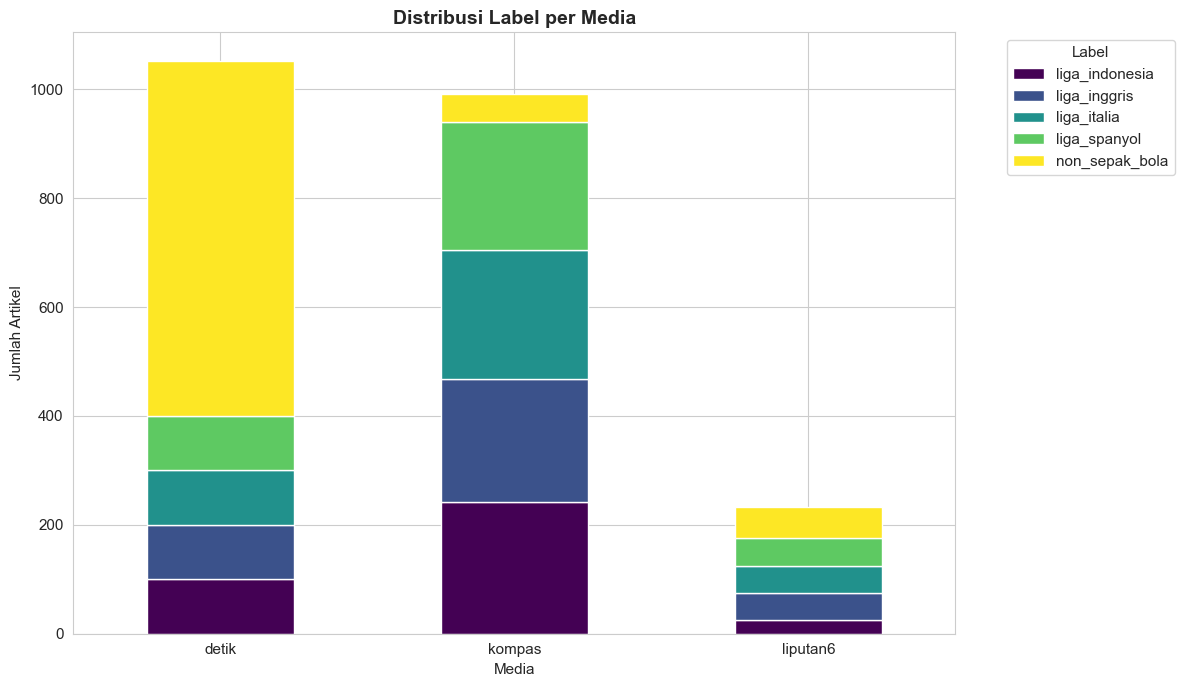


2. STATISTIK PANJANG KATA PER LABEL
----------------------------------------


E:\temp\ipykernel_31404\1844505060.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="word_count", data=df, palette="husl", ax=ax)


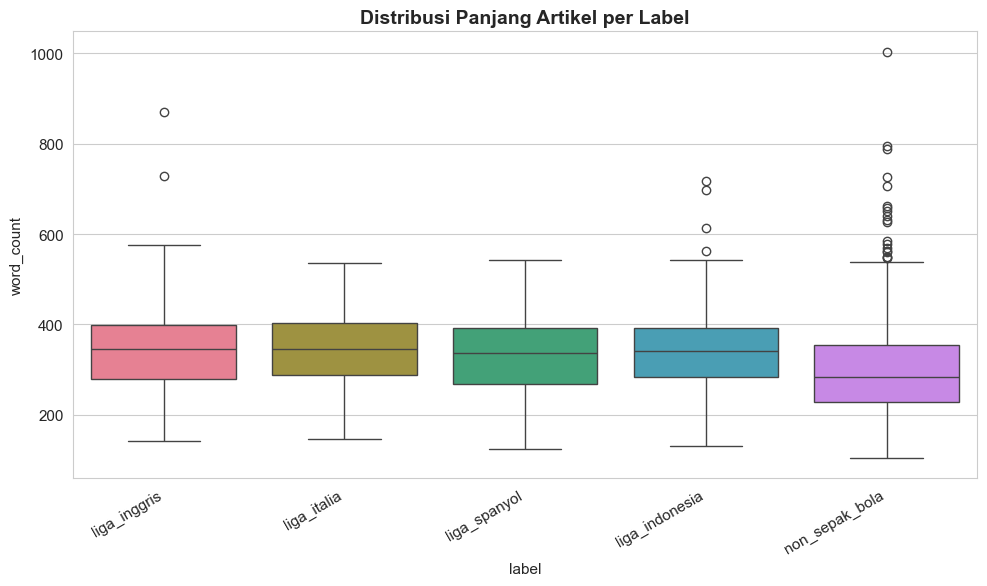


2. JUMLAH ARTIKEL PER MEDIA
----------------------------------------
media
detik       1052
kompas       992
liputan6     232


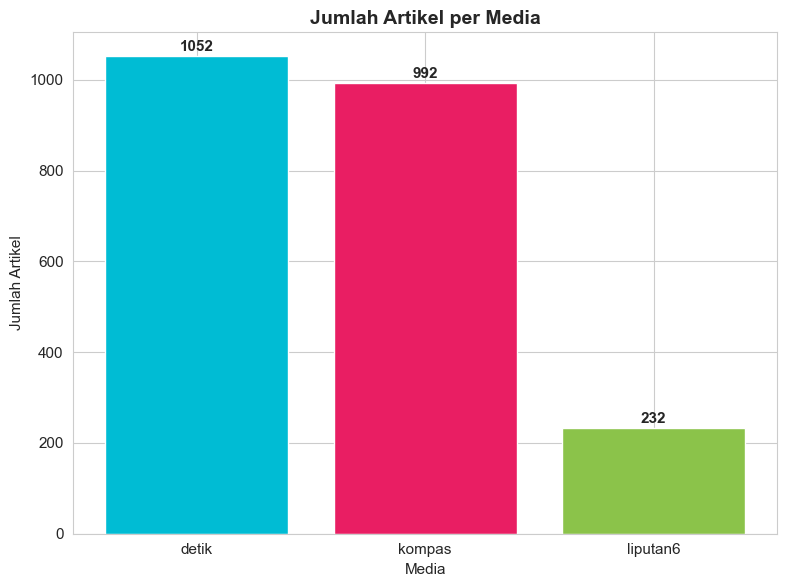


3. CROSS TABULATION: MEDIA vs LABEL
----------------------------------------
label     liga_indonesia  liga_inggris  liga_italia  liga_spanyol  non_sepak_bola  Total
media                                                                                   
detik                100           100          100           100             652   1052
kompas               242           226          236           236              52    992
liputan6              25            50           50            50              57    232
Total                367           376          386           386             761   2276


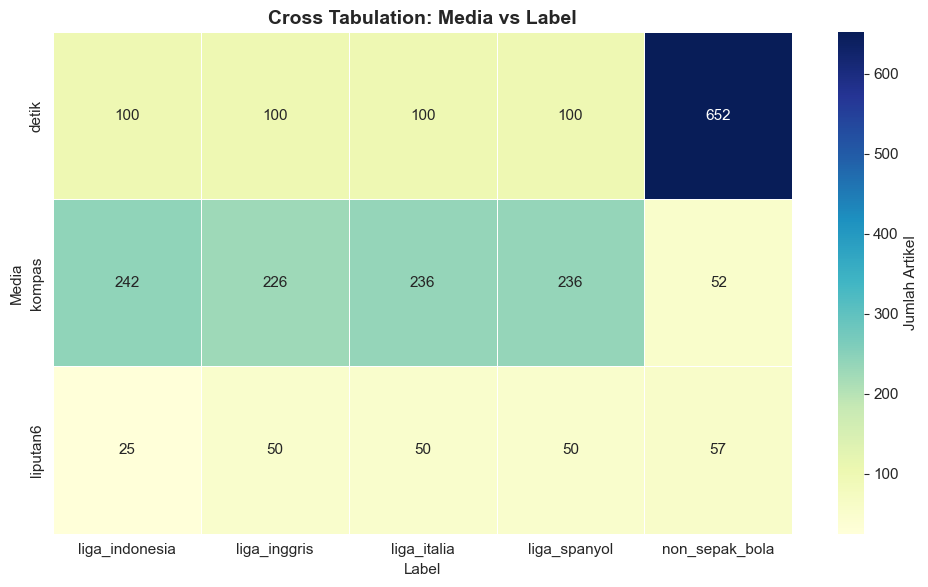


4. STATISTIK PANJANG TEKS (dalam kata)
----------------------------------------
count    2276.000000
mean      327.163884
std        95.563849
min       104.000000
25%       258.000000
50%       328.000000
75%       387.000000
max      1004.000000

Statistik per label:
                count        mean         std    min    25%    50%     75%     max
label                                                                             
liga_indonesia  367.0  341.623978   85.774423  130.0  283.5  340.0  392.00   718.0
liga_inggris    376.0  343.603723   94.222629  142.0  278.0  344.5  399.00   871.0
liga_italia     386.0  341.797927   82.127304  145.0  288.5  345.5  403.00   536.0
liga_spanyol    386.0  331.818653   87.778874  124.0  268.0  337.0  392.75   543.0
non_sepak_bola  761.0  302.283837  105.447896  104.0  229.0  283.0  354.00  1004.0


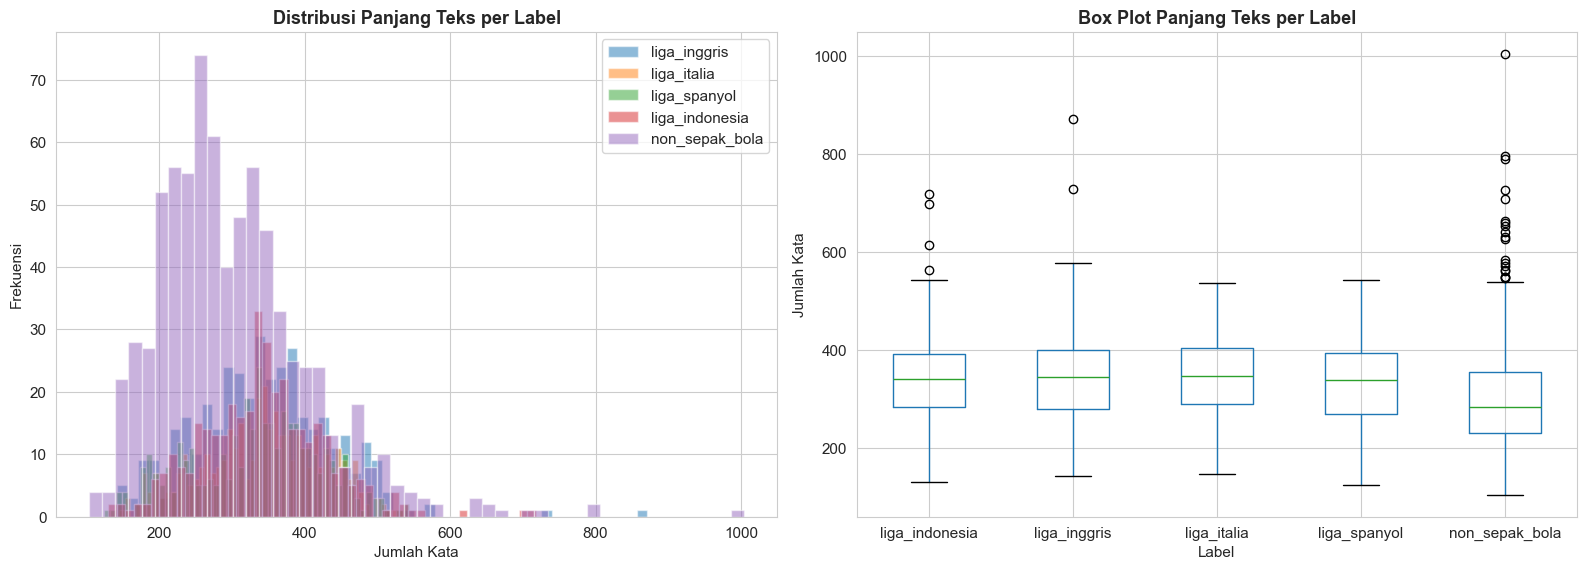


5. CONTOH ARTIKEL DARI SETIAP LABEL

--- Label: liga_indonesia ---
Media : detik
URL   : https://sport.detik.com/sepakbola/liga-indonesia/d-8527526/marselino-mungkin-batal-perkuat-timnas-indonesia-di-piala-aff
Date  : 
Kata  : 246
Text  : Marselino Mungkin Batal Perkuat Timnas Indonesia di Piala AFF. Marselino Ferdinan kemungkinan akan batal memperkuat Timnas Indonesia di Piala AFF 2026. Klubnya diyakini ogah melepas pemain selain agenda FIFA Matchday.
Awalnya Marselino disiapkan menjadi satu-satunya pemain abroad yang dipanggil untu...
------------------------------------------------------------

--- Label: liga_inggris ---
Media : detik
URL   : https://sport.detik.com/sepakbola/liga-inggris/d-8501164/enzo-fernandez-dan-joao-pedro-mau-cabut-dari-chelsea
Date  : 
Kata  : 184
Text  : Enzo Fernandez dan Joao Pedro Mau Cabut dari Chelsea?. Rumor transfer dari Chelsea. Dua pemain skuad utamanya, Enzo Fernandez dan Joao Pedro kabarnya mau pergi!
Chelsea babak belur di musim 2025/26. Dua ka

In [ ]:
def run_eda(df: pd.DataFrame) -> None:
    if len(df) == 0:
        print("Dataset kosong. EDA tidak dapat dijalankan.")
        return

    df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

    print("="*60)
    print("EXPLORATORY DATA ANALYSIS")
    print("="*60)

    print("\n1. DISTRIBUSI LABEL & MEDIA")
    print("-"*40)
    
    media_label_dist = pd.crosstab(df["media"], df["label"])
    
    fig, ax = plt.subplots(figsize=(12, 7))
    media_label_dist.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
    
    ax.set_title("Distribusi Label per Media", fontsize=14, fontweight="bold")
    ax.set_xlabel("Media")
    ax.set_ylabel("Jumlah Artikel")
    
    plt.xticks(rotation=0)
    plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "eda_media_label_dist.png"), dpi=150)
    plt.show()

    print("\n2. STATISTIK PANJANG KATA PER LABEL")
    print("-"*40)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(x="label", y="word_count", data=df, palette="husl", ax=ax)
    ax.set_title("Distribusi Panjang Artikel per Label", fontsize=14, fontweight="bold")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "eda_word_count_boxplot.png"), dpi=150)
    plt.show()

    print("\n2. JUMLAH ARTIKEL PER MEDIA")
    print("-"*40)
    media_counts = df["media"].value_counts()
    print(media_counts.to_string())

    fig, ax = plt.subplots(figsize=(8, 6))
    media_colors = ["#00BCD4", "#E91E63", "#8BC34A"]
    bars = ax.bar(media_counts.index, media_counts.values,
                  color=media_colors[:len(media_counts)])
    ax.set_title("Jumlah Artikel per Media", fontsize=14, fontweight="bold")
    ax.set_xlabel("Media")
    ax.set_ylabel("Jumlah Artikel")

    for bar, count in zip(bars, media_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                str(count), ha="center", va="bottom", fontweight="bold")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "eda_media_distribution.png"), dpi=150)
    plt.show()

    print("\n3. CROSS TABULATION: MEDIA vs LABEL")
    print("-"*40)
    crosstab = pd.crosstab(df["media"], df["label"], margins=True, margins_name="Total")
    print(crosstab.to_string())

    ct_no_margin = pd.crosstab(df["media"], df["label"])
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(ct_no_margin, annot=True, fmt="d", cmap="YlGnBu",
                linewidths=0.5, ax=ax, cbar_kws={"label": "Jumlah Artikel"})
    ax.set_title("Cross Tabulation: Media vs Label", fontsize=14, fontweight="bold")
    ax.set_xlabel("Label")
    ax.set_ylabel("Media")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "eda_crosstab_heatmap.png"), dpi=150)
    plt.show()

    print("\n4. STATISTIK PANJANG TEKS (dalam kata)")
    print("-"*40)
    print(df["word_count"].describe().to_string())

    print("\nStatistik per label:")
    label_stats = df.groupby("label")["word_count"].describe()
    print(label_stats.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax1 = axes[0]
    for label in df["label"].unique():
        subset = df[df["label"] == label]["word_count"]
        ax1.hist(subset, bins=50, alpha=0.5, label=label)
    ax1.set_title("Distribusi Panjang Teks per Label", fontsize=13, fontweight="bold")
    ax1.set_xlabel("Jumlah Kata")
    ax1.set_ylabel("Frekuensi")
    ax1.legend()

    ax2 = axes[1]
    df.boxplot(column="word_count", by="label", ax=ax2)
    ax2.set_title("Box Plot Panjang Teks per Label", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Label")
    ax2.set_ylabel("Jumlah Kata")
    plt.suptitle("") 

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "eda_text_length.png"), dpi=150)
    plt.show()

    print("\n5. CONTOH ARTIKEL DARI SETIAP LABEL")
    print("="*60)

    for label in sorted(df["label"].unique()):
        sample = df[df["label"] == label].iloc[0]
        print(f"\n--- Label: {label} ---")
        print(f"Media : {sample['media']}")
        print(f"URL   : {sample['url']}")
        print(f"Date  : {sample['date']}")
        print(f"Kata  : {sample['word_count']}")
        text_preview = sample["text"][:300]
        if len(sample["text"]) > 300:
            text_preview += "..."
        print(f"Text  : {text_preview}")
        print("-"*60)

    df.drop(columns=["word_count"], inplace=True, errors="ignore")

run_eda(df_final)

In [36]:
# Tutup HTTP session
http_client.close()
print("Proses selesai. Dataset siap digunakan untuk Soal 1c (IndoBERT fine-tuning).")

2026-06-24 18:36:53 [INFO] Session ditutup. Total request: 1751


Proses selesai. Dataset siap digunakan untuk Soal 1c (IndoBERT fine-tuning).
